<a href="https://colab.research.google.com/github/Karsuman4298/Deep-learning/blob/main/Research_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
seq_len = 8234

kv = torch.randn(2, seq_len, 64)
print("Transformer KV memory (MB):", kv.element_size() * kv.nelement() / 1e6)

state = torch.randn(2, 32)
print("Mamba state memory (MB):", state.element_size() * state.nelement() / 1e6)

Transformer KV memory (MB): 4.215808
Mamba state memory (MB): 0.000256


In [10]:
import torch
def parallel_scan(a, b):

    x = torch.zeros_like(b)
    for t in range(1, len(b)):
        x[t] = a[t] * x[t-1] + b[t]
    return x

a = torch.linspace(0.9, 0.99, 100)
b = torch.randn(100)
print(parallel_scan(a, b))

tensor([ 0.0000,  0.0978, -0.2363, -0.8450, -1.4360, -0.2421, -1.1185, -1.3591,
        -1.8332,  0.1469,  1.5497,  1.7550,  2.0466,  2.2325,  2.1741,  0.7846,
         1.8516,  2.4751,  1.0965,  1.7254,  1.7298,  0.6063,  1.1239,  0.3790,
        -0.1369, -1.0589,  0.3142, -0.7018,  1.1777, -0.1739, -1.3456, -1.1167,
        -0.7096, -1.3629, -2.3553, -2.0259, -2.1992, -1.4693,  0.6784,  1.0798,
        -0.0986, -0.8982, -0.3896,  0.6355, -0.8670, -0.3205, -0.5454, -0.8848,
         0.4817,  0.9049, -0.6906, -0.8245, -2.8407, -3.3212, -1.5297, -1.1453,
        -0.3735, -0.6813,  1.4056,  1.2403,  1.2343,  0.9003,  1.2769,  0.9401,
        -1.3451, -0.2042,  0.0332, -0.2920, -0.0499, -0.7544, -1.1655, -2.0828,
        -2.2341, -3.6852, -4.8215, -3.8246, -2.1433, -2.9651, -1.0000, -1.2493,
        -0.4183, -0.6055, -1.1776, -0.6676, -0.3156, -0.3372,  0.4504,  1.2605,
        -0.0100,  0.7591,  1.1355,  0.6816,  1.7273,  2.3274,  3.5040,  2.1764,
         1.1173,  0.5928,  1.2543,  1.35

In [11]:
a

tensor([0.9000, 0.9009, 0.9018, 0.9027, 0.9036, 0.9045, 0.9055, 0.9064, 0.9073,
        0.9082, 0.9091, 0.9100, 0.9109, 0.9118, 0.9127, 0.9136, 0.9145, 0.9155,
        0.9164, 0.9173, 0.9182, 0.9191, 0.9200, 0.9209, 0.9218, 0.9227, 0.9236,
        0.9245, 0.9255, 0.9264, 0.9273, 0.9282, 0.9291, 0.9300, 0.9309, 0.9318,
        0.9327, 0.9336, 0.9345, 0.9355, 0.9364, 0.9373, 0.9382, 0.9391, 0.9400,
        0.9409, 0.9418, 0.9427, 0.9436, 0.9445, 0.9455, 0.9464, 0.9473, 0.9482,
        0.9491, 0.9500, 0.9509, 0.9518, 0.9527, 0.9536, 0.9545, 0.9555, 0.9564,
        0.9573, 0.9582, 0.9591, 0.9600, 0.9609, 0.9618, 0.9627, 0.9636, 0.9645,
        0.9655, 0.9664, 0.9673, 0.9682, 0.9691, 0.9700, 0.9709, 0.9718, 0.9727,
        0.9736, 0.9745, 0.9755, 0.9764, 0.9773, 0.9782, 0.9791, 0.9800, 0.9809,
        0.9818, 0.9827, 0.9836, 0.9845, 0.9855, 0.9864, 0.9873, 0.9882, 0.9891,
        0.9900])

In [4]:
b

tensor([-0.6390, -0.0855,  0.7602,  0.0415, -1.5451, -2.4722, -0.0594,  1.2774,
        -1.2299, -1.4296,  1.4926,  2.2214, -0.2337, -1.3245,  0.5047, -0.1392,
         0.5880, -0.3806, -0.7604, -1.3909, -0.9817, -0.5245, -0.7211,  0.3939,
         1.0980, -1.8752, -0.1747,  1.0780, -0.8044,  1.0059, -1.0796,  1.9918,
         0.0214, -2.6536, -0.4535, -0.7643,  0.8908,  0.5121, -0.4782, -0.1965,
        -0.8087,  0.2285, -0.1394, -0.1323, -0.4142, -0.9679,  0.1867,  0.7664,
        -0.4992, -1.9923,  0.5823, -0.7847, -1.4649,  0.7435,  0.4227,  0.9283,
         0.3227, -2.5795,  0.5364,  0.8865,  0.6970,  0.6785, -0.0280, -0.3690,
         0.0464, -1.7623, -1.1366, -1.4504,  1.1862,  1.4450,  0.4974,  0.3660,
         0.2395, -0.6621, -0.1104,  0.3898,  0.0501, -1.2666, -0.8316,  0.3668,
         0.2720,  1.1599,  0.7046, -0.4621,  0.2389, -0.0195,  0.9963, -0.0154,
         0.4410, -0.8329,  0.0616,  0.6292, -1.5538,  0.8013, -1.5500, -0.1828,
        -0.1545, -0.1743,  0.1477, -1.18

Number of patches: 784


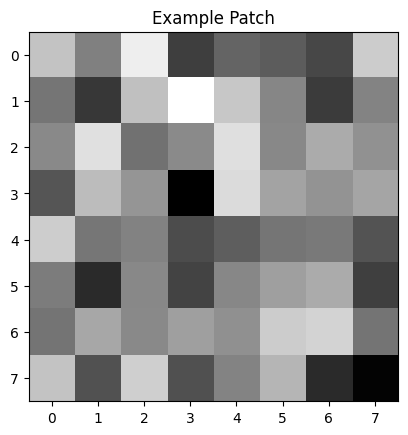

In [15]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import requests
# Dummy image for demo
img = torch.randn(1, 3, 224, 224)
patch_size = 8
patches = img.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size).reshape(1, 3, -1, patch_size**2).permute(0, 2, 1, 3).flatten(2)
print("Number of patches:", patches.shape[1])
plt.imshow(patches[0, 0, :patch_size**2].reshape(patch_size, patch_size), cmap='gray'); plt.title("Example Patch"); plt.show()